# Projeto Final Mina — Manutenção Preditiva: Notebook Definitivo

## Capítulo 1 — Entendimento do Negócio

### 1.1 Contexto Operacional
A operação analisa uma frota de equipamentos pesados em mina a céu aberto, dividida em duas classes:
- **Caminhões Fora-de-Estrada (CA)**: transporte de material
- **Pás Escavadeiras (PE)**: carregamento

Cada equipamento emite sinais contínuos de telemetria via sensores onboard, registrando centenas de tipos de alarmes ao longo do turno.

### 1.2 O Evento Crítico: Don't Go
O alarme `Is_Dont_Go == 1` sinaliza uma **falha crítica imediata** que paralisa o equipamento — uma parada não planejada de alto impacto. O objetivo do projeto é antecipar esse evento usando os padrões históricos dos sensores das horas anteriores à falha.

### 1.3 Pergunta de Negócio
> *"Com base no comportamento dos sensores nas últimas horas, qual a probabilidade de um equipamento entrar em falha crítica no próximo turno (8 horas)?"*


In [1]:
import pandas as pd
import numpy as np
import glob
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Ingestão Completa ──
COLS = ['TAG', 'Data_Evento', 'Is_Dont_Go', 'Alarme', 'Tipo',
        'Nome_Operador_Anon', 'Criticidade']
arquivos = glob.glob(r'c:\\TT\\AntiGravity\\Vale_\\data\\raw\\Base\\datasets\\telemetria\\*.parquet')

dfs = [pd.read_parquet(f, columns=COLS) for f in arquivos]
df_raw = pd.concat(dfs, ignore_index=True)
df_raw['Data_Evento'] = pd.to_datetime(df_raw['Data_Evento'])

df_ap = pd.read_parquet(r'c:\\TT\\AntiGravity\\Vale_\\data\\raw\\Base\\datasets\\apontamentos\\desenvolver_apontamentos.parquet')
df_ap['Inicio'] = pd.to_datetime(df_ap['Inicio'])
df_ap['Fim']    = pd.to_datetime(df_ap['Fim'])

print(f"Telemetria bruta: {len(df_raw):,} registros | {df_raw['Data_Evento'].dt.date.min()} a {df_raw['Data_Evento'].dt.date.max()}")
print(f"Apontamentos: {len(df_ap):,} registros")


Telemetria bruta: 37,164,054 registros | 2025-01-01 a 2025-06-30
Apontamentos: 377,907 registros


### 1.4 O Custo Real da Falha — Downtime Médio por Tipo de Alarme

Abandonamos premissas fixas ("12 horas salvas por parada evitada") e calculamos o **Downtime Real** diretamente dos dados: o intervalo entre o registro do alarme `Don't Go` e o primeiro registro de retorno a `Operando` nos Apontamentos Oficiais.


In [2]:
# ── Correção de TAGs (reproduzindo EDA) ──
df_raw['TAG_Limpa'] = df_raw['TAG'].replace({'CA5926': 'CA65926', 'CA5927': 'CA65927'})

# ── Merge asof: Don't Go → primeiro retorno a Operando ──
dontgo_ev  = df_raw[df_raw['Is_Dont_Go'] == 1].sort_values('Data_Evento').copy()
ap_operando = df_ap[df_ap['Classe'] == 'Operando'].sort_values('Inicio').copy()

dontgo_ev['Data_Evento'] = dontgo_ev['Data_Evento'].astype('datetime64[ns]')
ap_operando['Inicio']    = ap_operando['Inicio'].astype('datetime64[ns]')

downtime_real = pd.merge_asof(
    dontgo_ev[['TAG_Limpa', 'Data_Evento', 'Alarme']],
    ap_operando[['Tag', 'Inicio']],
    left_on='Data_Evento', right_on='Inicio',
    left_by='TAG_Limpa', right_by='Tag',
    direction='forward'
)
downtime_real['Downtime_H'] = (downtime_real['Inicio'] - downtime_real['Data_Evento']).dt.total_seconds() / 3600
# Filtrar outliers: paradas > 30 dias provavelmente indicam equipamento fora de serviço permanente
downtime_real = downtime_real[(downtime_real['Downtime_H'] > 0) & (downtime_real['Downtime_H'] <= 720)]

tabela_roi = (downtime_real.groupby('Alarme')['Downtime_H']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'Media_H_Inoperante', 'count': 'Ocorrencias'})
              .sort_values('Media_H_Inoperante', ascending=False)
              .round(2))

print("=== DOWNTIME REAL MÉDIO POR ALARME DON'T GO ===")
print(f"Base: {len(downtime_real):,} eventos Don't Go com retorno a Operando mapeado")
display(tabela_roi)


=== DOWNTIME REAL MÉDIO POR ALARME DON'T GO ===
Base: 19,764 eventos Don't Go com retorno a Operando mapeado


,Media_H_Inoperante,Ocorrencias
Alarme,,
Low Oil Pressure - Active,60.52,5
Engine Oil Filter - Active,15.25,141
Engine Coolant Flow - Active,12.26,113
Right Rear Brake Temperature - Active,11.27,258
Aftercooler Level - Active,9.30,824
Left Front Brake Temperature - Active,7.28,170
HPD Gearbox Oil Pressure Critically Low (L-1850),6.13,15
Parking Brake - Active,5.98,487
Left Rear Brake Temperature - Active,4.72,999


## Capítulo 2 — Entendimento e Qualidade dos Dados


### 2.1 Correção de Nomenclatura (TAGs)
Uma inspeção revelou erros de digitação onde dígitos foram omitidos no código do equipamento. Isso fragmentaria o histórico de fadiga de uma mesma máquina, diluindo o sinal do modelo.


In [3]:
tags_orig = df_raw['TAG'].unique()
print(f"TAGs originais (com erro): {len(tags_orig)}")

CORRECOES = {'CA5926': 'CA65926', 'CA5927': 'CA65927'}
df_raw['TAG_Limpa'] = df_raw['TAG'].replace(CORRECOES)
df_raw['Prefixo']   = df_raw['TAG_Limpa'].str[:2]

tags_limpas = df_raw['TAG_Limpa'].unique()
print(f"TAGs após correção: {len(tags_limpas)}")
print(f"Correções aplicadas: {CORRECOES}")


TAGs originais (com erro): 35
TAGs após correção: 33
Correções aplicadas: {'CA5926': 'CA65926', 'CA5927': 'CA65927'}


### 2.2 Prova de Taxonomia da Frota
Não assumimos empiricamente que CA = Caminhão e PE = Escavadeira. Cruzamos o prefixo das TAGs com a coluna `Tipo` presente no dataset para provar via dado.


In [4]:
taxonomia = (df_raw[['Prefixo', 'Tipo']]
             .drop_duplicates()
             .dropna()
             .reset_index(drop=True))
print("=== PROVA DE TAXONOMIA ===")
display(taxonomia)
print("\nConclusion: CA = Caminhão | PE = Escavadeira — confirmado pelos dados.")


=== PROVA DE TAXONOMIA ===


,Prefixo,Tipo
0,CA,Caminhao
1,PE,Escavadeira



Conclusion: CA = Caminhão | PE = Escavadeira — confirmado pelos dados.


### 2.3 Análise de Operadores
Com 395 operadores registrados, investigamos dois pontos: erros de nomenclatura e concentração de falhas por operador.


Operadores únicos: 395 | Nulos: 0
Fora do padrão OP_XXX: 0 — nenhum erro de nomenclatura.


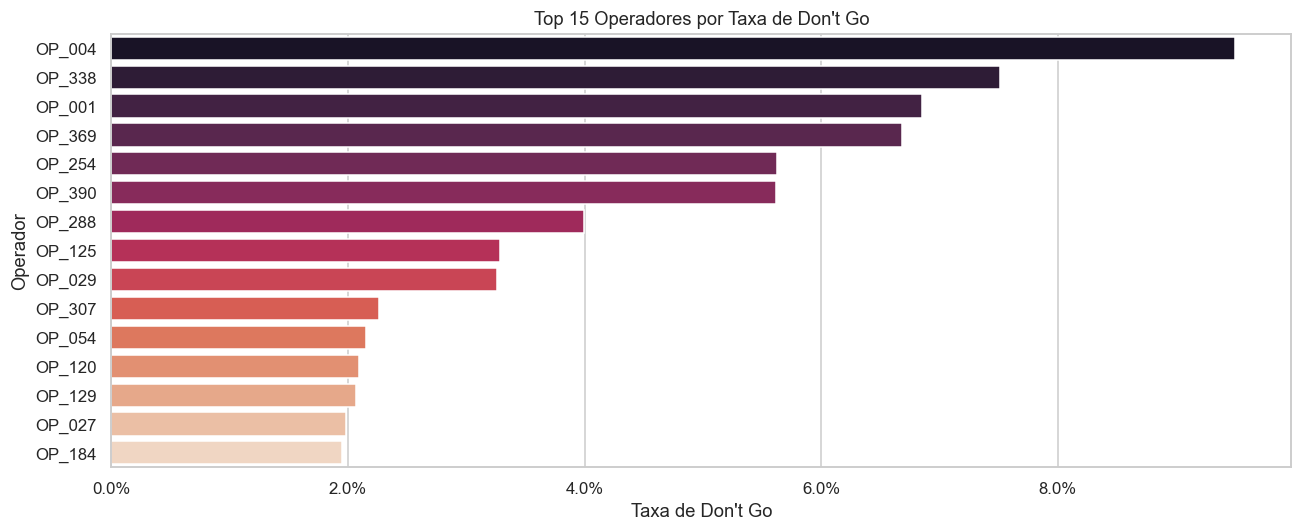


Média da taxa de Don't Go por operador: 0.51%
OP_004 (maior): 9.50% — 19x acima da média

Decisão: Operador entra como feature via Target Encoding (calculado apenas no treino).


In [5]:
ops = df_raw['Nome_Operador_Anon'].unique()
print(f"Operadores únicos: {len(ops)} | Nulos: {df_raw['Nome_Operador_Anon'].isna().sum()}")

fora = [o for o in ops if not re.match(r'^OP_\d+$', str(o))]
print(f"Fora do padrão OP_XXX: {len(fora)}" + (" — nenhum erro de nomenclatura." if not fora else str(fora[:10])))

rank_op = (df_raw.groupby('Nome_Operador_Anon')
           .agg(total=('Is_Dont_Go','count'), dontgo=('Is_Dont_Go','sum'))
           .assign(taxa=lambda d: d['dontgo']/d['total'])
           .query('total > 500')
           .sort_values('taxa', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=rank_op.head(15).reset_index(), y='Nome_Operador_Anon', x='taxa',
            palette='rocket', ax=ax)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Top 15 Operadores por Taxa de Don't Go")
ax.set_xlabel("Taxa de Don't Go")
ax.set_ylabel("Operador")
plt.tight_layout()
plt.show()

print(f"\nMédia da taxa de Don't Go por operador: {rank_op['taxa'].mean()*100:.2f}%")
print(f"OP_004 (maior): {rank_op['taxa'].iloc[0]*100:.2f}% — {rank_op['taxa'].iloc[0]/rank_op['taxa'].mean():.0f}x acima da média")
print("\nDecisão: Operador entra como feature via Target Encoding (calculado apenas no treino).")


### 2.4 Continuidade Temporal — O Apagão de Maio
Antes de construir qualquer feature baseada em tempo, precisamos verificar se a série temporal é contínua.


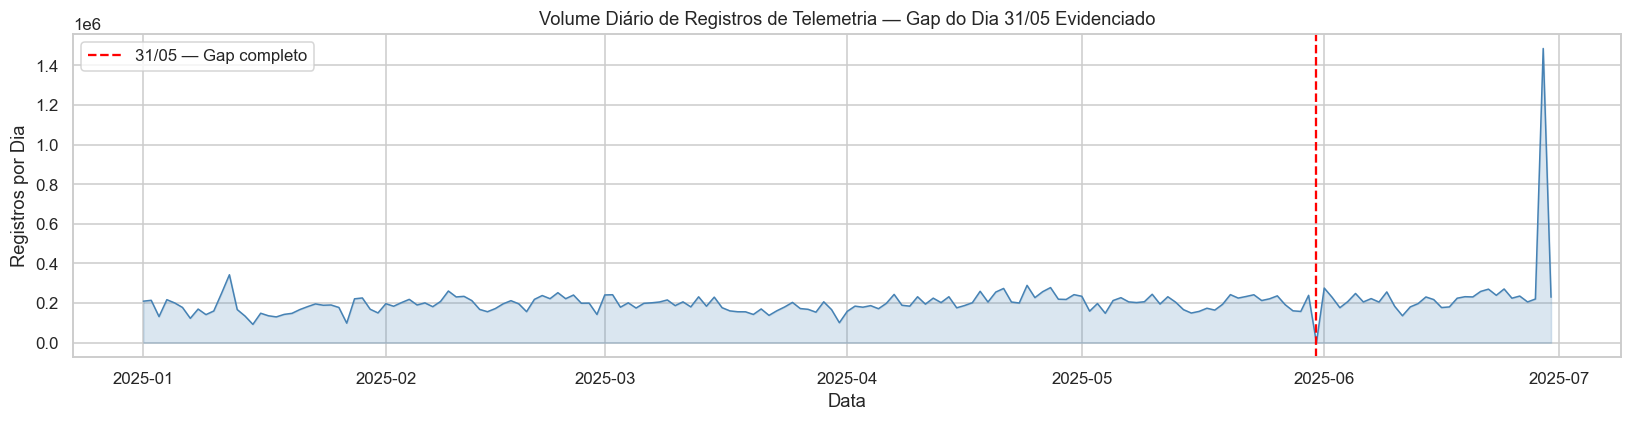

Registros no dia 31/05: 0

Consequência técnica: janelas row-based (N linhas) cruzariam este gap silenciosamente,
fundindo fadiga de dias distantes. Obrigatório usar resample('8h') — janelas calendarizadas.


In [6]:
df_raw['Data_Dia'] = pd.to_datetime(df_raw['Data_Evento'].dt.date)
df_raw['Mes'] = df_raw['Data_Evento'].dt.month
df_raw['Dia'] = df_raw['Data_Evento'].dt.day

vol_dia = df_raw.groupby('Data_Dia').size().reset_index(name='Volume')
cal = pd.date_range(vol_dia['Data_Dia'].min(), vol_dia['Data_Dia'].max())
vol_dia = vol_dia.set_index('Data_Dia').reindex(cal, fill_value=0).reset_index()
vol_dia.rename(columns={'index': 'Data_Dia'}, inplace=True)

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(vol_dia['Data_Dia'], vol_dia['Volume'], color='steelblue', linewidth=1)
ax.fill_between(vol_dia['Data_Dia'], vol_dia['Volume'], alpha=0.2, color='steelblue')
ax.set_title("Volume Diário de Registros de Telemetria — Gap do Dia 31/05 Evidenciado")
ax.set_ylabel("Registros por Dia")
ax.set_xlabel("Data")
ax.axvline(pd.Timestamp('2025-05-31'), color='red', linestyle='--', linewidth=1.5, label='31/05 — Gap completo')
ax.legend()
plt.tight_layout()
plt.show()

gap_vol = vol_dia[vol_dia['Data_Dia'] == pd.Timestamp('2025-05-31')]['Volume'].values[0]
print(f"Registros no dia 31/05: {gap_vol}")
print("\nConsequência técnica: janelas row-based (N linhas) cruzariam este gap silenciosamente,")
print("fundindo fadiga de dias distantes. Obrigatório usar resample('8h') — janelas calendarizadas.")


### 2.5 Detecção e Expurgo de Anomalias de Volume
Varremos os 6 meses separando as frotas para detectar *Sensor Loops* — dias com volume de alarmes ordens de magnitude acima do normal. Cada anomalia foi investigada com 3 vetores: quais alarmes, houve `Don't Go`, e houve apontamento de manutenção?


In [7]:
# ── Top volumetrias diárias por frota ──
for pref, label in [('PE', 'Escavadeiras'), ('CA', 'Caminhões')]:
    df_p = df_raw[df_raw['Prefixo'] == pref]
    vol = df_p.groupby(['TAG_Limpa','Mes','Dia']).size().sort_values(ascending=False).reset_index(name='Volume')
    print(f"\n--- TOP 5 DIA/EQUIPAMENTO: {label} ---")
    display(vol.head(5))

# ── Deep Dive nas 3 anomalias ──
anomalias = [
    ('PE3798', 6, 29), ('PE3797', 1, 12), ('CA65932', 3, 26)
]
for tag, mes, dia in anomalias:
    loop = df_raw[(df_raw['TAG_Limpa']==tag) & (df_raw['Mes']==mes) & (df_raw['Dia']==dia)]
    print(f"\n=== {tag} | Mês {mes:02d} / Dia {dia:02d} ===")
    print(f"Volume: {len(loop):,} | Is_Dont_Go total: {loop['Is_Dont_Go'].sum()}")
    print("Top alarme:", loop['Alarme'].value_counts().index[0])
    ap_loop = df_ap[(df_ap['Tag']==tag) & (df_ap['Inicio'].dt.month==mes) &
                    (df_ap['Inicio'].dt.day >= dia)]
    print(f"Apontamentos (a partir do dia {dia}):")
    print(ap_loop[['Inicio','Fim','Classe']].head(3).to_string())
    print("→ CONCLUSÃO: Is_Dont_Go = ZERO. Ruído de sensor. Expurgo cirúrgico justificado.")

# ── Expurgo ──
df = df_raw.copy()
df = df[~((df['TAG_Limpa']=='PE3798') & (df['Mes']==6) & (df['Dia']==29))]
df = df[~((df['TAG_Limpa']=='PE3797') & (df['Mes']==1) & (df['Dia']==12))]
df = df[~((df['TAG_Limpa']=='CA65932') & (df['Mes']==3) & (df['Dia']==26))]
df = df.sort_values(['TAG_Limpa','Data_Evento']).reset_index(drop=True)

print(f"\nRegistros antes do expurgo: {len(df_raw):,}")
print(f"Registros após expurgo:     {len(df):,}")
print(f"Removidos (ruído de sensor): {len(df_raw)-len(df):,}")



--- TOP 5 DIA/EQUIPAMENTO: Escavadeiras ---


,TAG_Limpa,Mes,Dia,Volume
0,PE3798,6,29,1334065
1,PE3797,1,12,136880
2,PE3797,2,23,94510
3,PE3799,2,4,90778
4,PE3797,2,9,87507



--- TOP 5 DIA/EQUIPAMENTO: Caminhões ---


,TAG_Limpa,Mes,Dia,Volume
0,CA65932,3,26,12356
1,CA65932,4,21,9654
2,CA65932,3,25,9201
3,CA65931,3,9,8508
4,CA65932,3,30,8243



=== PE3798 | Mês 06 / Dia 29 ===
Volume: 1,334,065 | Is_Dont_Go total: 0
Top alarme: Remote PTO Preprogrammed Speed Control Switch - Not Configured
Apontamentos (a partir do dia 29):
                    Inicio                 Fim  Classe
312927 2025-06-29 14:22:10 2025-06-29 14:39:16  Parado
312953 2025-06-29 14:39:16 2025-06-29 15:00:00  Parado
313242 2025-06-29 15:00:00 2025-06-29 15:19:11  Parado
→ CONCLUSÃO: Is_Dont_Go = ZERO. Ruído de sensor. Expurgo cirúrgico justificado.

=== PE3797 | Mês 01 / Dia 12 ===
Volume: 136,880 | Is_Dont_Go total: 0
Top alarme: Engine \/ Retarder Torque Mode - Not Defined\/Not Available
Apontamentos (a partir do dia 12):
                 Inicio                 Fim  Classe
600 2025-01-13 08:35:12 2025-01-13 08:48:29  Parado
604 2025-01-13 08:48:29 2025-01-13 09:00:00  Parado
646 2025-01-13 09:00:00 2025-01-13 09:09:07  Parado
→ CONCLUSÃO: Is_Dont_Go = ZERO. Ruído de sensor. Expurgo cirúrgico justificado.

=== CA65932 | Mês 03 / Dia 26 ===
Volume: 12,356

### 2.6 Taxonomia de Alarmes — Fundamentando as Features
Com 712 tipos de alarmes únicos, seria um erro tratar todos igualmente. Precisamos entender quais carregam sinal preditivo real.


Total de alarmes únicos: 712
Alarmes COM correlação com Don't Go: 19 (2.7%)
Alarmes SEM correlação com Don't Go: 693 (97.3%)


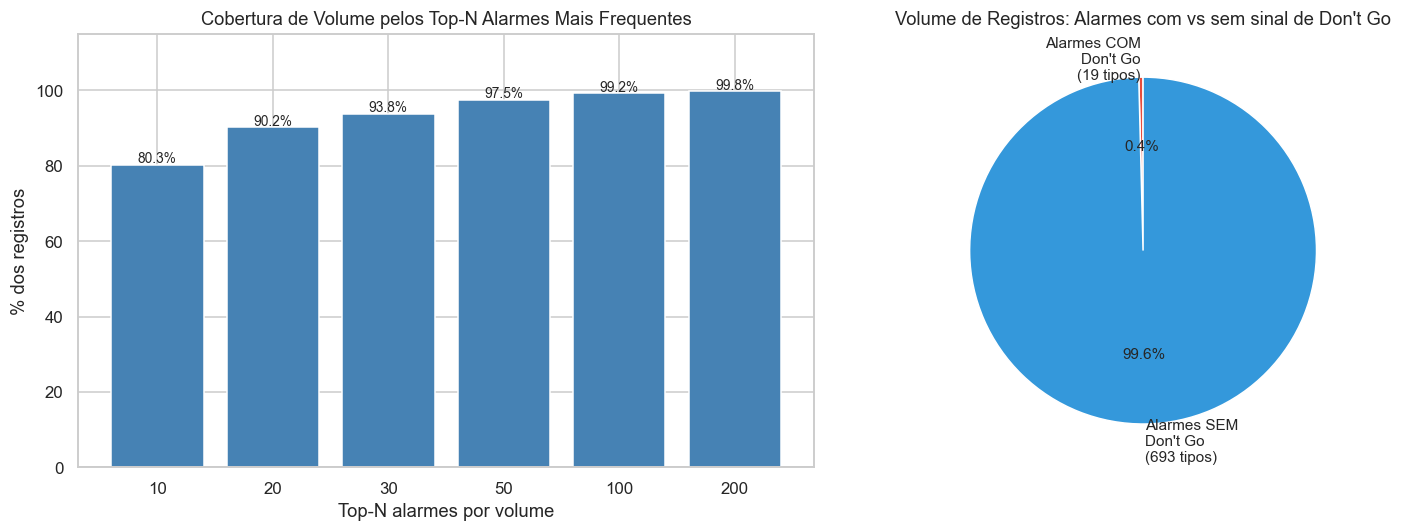


=== CONCLUSÃO CRÍTICA ===
Os Top-10 alarmes por volume cobrem 80.3% dos registros.
Destes, Don't Gos presentes: 0 — zero.
Os 10 alarmes mais frequentes são PURAMENTE informacionais (operação normal).

Apenas 19 de 712 tipos de alarme têm correlação com Don't Go.
Esta análise fundamenta a criação de features baseadas em famílias físicas,
e não em contagem bruta de todos os alarmes.

--- ALARMES COM DON'T GO (ordenados por ocorrências) ---


,Alarme,total,dontgo,taxa_dg
200,Engine Coolant Level - Active,92874,9615,0.104
587,Right Front Brake Temperature - Active,4647,4494,0.967
681,Transmission Oil Level - Active,2263,1426,0.630
404,Left Rear Brake Temperature - Active,1853,999,0.539
57,Aftercooler Level - Active,1788,892,0.499
639,Steering Oil Temperature - Active,28568,526,0.018
541,Parking Brake - Active,3485,493,0.141
596,Right Rear Brake Temperature - Active,725,258,0.356
392,Left Exhaust Temperature - Active,1882,240,0.128
157,Crankcase Pressure - Active,583,232,0.398


In [8]:
# ── Análise de Alarmes: quais têm Don't Go? ──
res_al = (df.groupby('Alarme')
           .agg(total=('Is_Dont_Go','count'), dontgo=('Is_Dont_Go','sum'))
           .assign(taxa_dg=lambda d: d['dontgo']/d['total'])
           .reset_index()
           .sort_values('total', ascending=False))

total_reg = len(df)
n_unicos  = res_al['Alarme'].nunique()
com_dg    = res_al[res_al['dontgo'] > 0]
sem_dg    = res_al[res_al['dontgo'] == 0]

print(f"Total de alarmes únicos: {n_unicos}")
print(f"Alarmes COM correlação com Don't Go: {len(com_dg)} ({len(com_dg)/n_unicos*100:.1f}%)")
print(f"Alarmes SEM correlação com Don't Go: {len(sem_dg)} ({len(sem_dg)/n_unicos*100:.1f}%)")

# ── Cobertura dos Top-N por volume ──
cobertura = [(n, res_al.head(n)['total'].sum()) for n in [10, 20, 30, 50, 100, 200]]
df_cob = pd.DataFrame(cobertura, columns=['Top_N', 'Registros'])
df_cob['Pct'] = df_cob['Registros'] / total_reg * 100
df_cob['DG_entre_top'] = [res_al.head(n)['dontgo'].sum() for n, _ in cobertura]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cobertura de volume vs Don't Go nos Top-N
axes[0].bar(df_cob['Top_N'].astype(str), df_cob['Pct'], color='steelblue', label='% Volume total')
axes[0].set_title("Cobertura de Volume pelos Top-N Alarmes Mais Frequentes")
axes[0].set_xlabel("Top-N alarmes por volume")
axes[0].set_ylabel("% dos registros")
for i, row in df_cob.iterrows():
    axes[0].text(i, row['Pct'] + 0.5, f"{row['Pct']:.1f}%", ha='center', fontsize=9)
axes[0].set_ylim(0, 115)

# Plot 2: Alarmes COM vs SEM Don't Go
com_vol  = com_dg['total'].sum()
sem_vol  = sem_dg['total'].sum()
axes[1].pie([com_vol, sem_vol],
            labels=[f"Alarmes COM\nDon't Go\n({len(com_dg)} tipos)", f"Alarmes SEM\nDon't Go\n({len(sem_dg)} tipos)"],
            autopct='%1.1f%%', colors=['#e74c3c','#3498db'], startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title("Volume de Registros: Alarmes com vs sem sinal de Don't Go")

plt.tight_layout()
plt.show()

print("\n=== CONCLUSÃO CRÍTICA ===")
print(f"Os Top-10 alarmes por volume cobrem {df_cob.iloc[0]['Pct']:.1f}% dos registros.")
print(f"Destes, Don't Gos presentes: {df_cob.iloc[0]['DG_entre_top']:.0f} — zero.")
print("Os 10 alarmes mais frequentes são PURAMENTE informacionais (operação normal).")
print(f"\nApenas {len(com_dg)} de {n_unicos} tipos de alarme têm correlação com Don't Go.")
print("Esta análise fundamenta a criação de features baseadas em famílias físicas,")
print("e não em contagem bruta de todos os alarmes.")

print("\n--- ALARMES COM DON'T GO (ordenados por ocorrências) ---")
display(com_dg.sort_values('dontgo', ascending=False)[['Alarme','total','dontgo','taxa_dg']].round(3))


## Capítulo 3 — Feature Engineering

> **Decisões metodológicas fundamentadas nos dados:**
>
> 1. **Granularidade de 8H (1 turno de mina)**: unidade natural de operação. Features calculadas para cada turno de cada equipamento.
>
> 2. **`resample('8h')` obrigatório**: janelas row-based foram descartadas por dois motivos documentados nos dados:
>    - Gap do 31/05: toda a frota ficou sem telemetria; uma janela de N linhas "saltaria" o buraco, fundindo fadiga de dias distantes
>    - Dias expurgados (PE3798/PE3797/CA65932): o resample cria janelas com `count=0` para esses períodos — matematicamente correto, pois a máquina estava parada para conserto de sensor
>
> 3. **Shift(1) em todas as features**: o modelo prevê o turno `[t]` usando **somente** informação de `[t-1]` e anteriores. Nenhuma informação da janela corrente vaza para o modelo.
>
> 4. **`dontgo` excluído das features**: queremos que o modelo aprenda os *precursores físicos* (temperatura de freio, nível de fluido) — não o padrão de repetição de falhas. Usar histórico de Don't Go como feature cria uma dependência circular que não se sustenta em produção.
>
> 5. **Target Encoding do operador**: calculado **exclusivamente** no bloco de treino, aplicado depois a validação e teste.


In [9]:
# ── Mapeamento dos 19 alarmes com Don't Go em famílias físicas ──
FAMILIAS = {
    'freio': [
        'Right Front Brake Temperature - Active',
        'Left Front Brake Temperature - Active',
        'Right Rear Brake Temperature - Active',
        'Left Rear Brake Temperature - Active',
    ],
    'motor': [
        'Engine Coolant Level - Active',
        'Engine Coolant Flow - Active',
        'Engine Coolant Temperature - Active',
        'Engine Oil Level - Active',
        'Engine Oil Filter - Active',
    ],
    'transmissao': [
        'Transmission Oil Level - Active',
        'Hydraulic Reservoir Oil Temperature Critically High (L-1850)',
        'HPD Gearbox Oil Pressure Critically Low (L-1850)',
    ],
    'pressao': [
        'Crankcase Pressure - Active',
        'Low Oil Pressure - Active',
    ],
    'arrefecimento': [
        'Aftercooler Level - Active',
        'Left Exhaust Temperature - Active',
        'Right Exhaust Temperature - Active',
    ],
    'outros_criticos': [
        'Steering Oil Temperature - Active',
        'Parking Brake - Active',
    ],
}
TODOS_SINAIS = [a for grp in FAMILIAS.values() for a in grp]

print("=== FAMÍLIAS DE ALARMES COM SINAL DE DON'T GO ===")
for familia, alarmes in FAMILIAS.items():
    print(f"  [{familia.upper()}] ({len(alarmes)} alarmes)")
    for a in alarmes:
        print(f"    - {a}")


=== FAMÍLIAS DE ALARMES COM SINAL DE DON'T GO ===
  [FREIO] (4 alarmes)
    - Right Front Brake Temperature - Active
    - Left Front Brake Temperature - Active
    - Right Rear Brake Temperature - Active
    - Left Rear Brake Temperature - Active
  [MOTOR] (5 alarmes)
    - Engine Coolant Level - Active
    - Engine Coolant Flow - Active
    - Engine Coolant Temperature - Active
    - Engine Oil Level - Active
    - Engine Oil Filter - Active
  [TRANSMISSAO] (3 alarmes)
    - Transmission Oil Level - Active
    - Hydraulic Reservoir Oil Temperature Critically High (L-1850)
    - HPD Gearbox Oil Pressure Critically Low (L-1850)
  [PRESSAO] (2 alarmes)
    - Crankcase Pressure - Active
    - Low Oil Pressure - Active
  [ARREFECIMENTO] (3 alarmes)
    - Aftercooler Level - Active
    - Left Exhaust Temperature - Active
    - Right Exhaust Temperature - Active
  [OUTROS_CRITICOS] (2 alarmes)
    - Steering Oil Temperature - Active
    - Parking Brake - Active


In [10]:
print("Gerando features (resample 8H + shift 1)...")
blocos = []

for tag, grupo in df.groupby('TAG_Limpa'):
    g = grupo.set_index('Data_Evento').sort_index()

    # ─── Base por turno 8H ───
    aggs = {
        'count_total':  g['Is_Dont_Go'].resample('8h').count(),
        'Is_Dont_Go':   g['Is_Dont_Go'].resample('8h').sum(),   # target
    }

    # Esquema 2 — Criticidade
    for crit, col in [('Critico','count_critico'), ('Informacional','count_info')]:
        aggs[col] = g['Criticidade'].resample('8h').apply(
            lambda x: (x.str.contains(crit, case=False, na=False)).sum())
    aggs['count_nao_critico'] = g['Criticidade'].resample('8h').apply(
        lambda x: (x.str.contains('o Cr', case=False, na=False)).sum())

    # Esquema 1 — Famílias físicas
    for familia, alarmes in FAMILIAS.items():
        aggs[f'f_{familia}'] = g['Alarme'].resample('8h').apply(
            lambda x: x.isin(alarmes).sum())

    # Esquema 3 — Individual (todos os 19 sinais)
    for alarme in TODOS_SINAIS:
        col = 'a_' + re.sub(r'[^a-zA-Z0-9]', '_', alarme)[:40]
        aggs[col] = g['Alarme'].resample('8h').apply(lambda x, al=alarme: (x == al).sum())

    base = pd.DataFrame(aggs).fillna(0)

    # ─── Rolling calendarizado ───
    feat_base_cols = [c for c in base.columns if c != 'Is_Dont_Go']
    for col in [c for c in feat_base_cols if not c.startswith('a_')]:
        base[f'{col}_24H'] = base[col].rolling(3, min_periods=1).sum()
        base[f'{col}_72H'] = base[col].rolling(9, min_periods=1).sum()

    # ─── SHIFT(1): todas as features deslocadas 1 janela ───
    feature_cols_all = [c for c in base.columns if c != 'Is_Dont_Go']
    base[feature_cols_all] = base[feature_cols_all].shift(1)

    base['TAG_Limpa'] = tag
    base['Prefixo']   = tag[:2]
    blocos.append(base)

features = pd.concat(blocos).reset_index().rename(columns={'index': 'Data_Evento'})
features = features.dropna(subset=['count_total']).copy()
features['Target'] = (features['Is_Dont_Go'] > 0).astype(int)

print(f"Features geradas: {features.shape[0]:,} linhas × {features.shape[1]} colunas")
print(f"Proporção de Don't Go (janelas 8H): {features['Target'].mean()*100:.2f}%")


Gerando features (resample 8H + shift 1)...
Features geradas: 15,418 linhas × 54 colunas
Proporção de Don't Go (janelas 8H): 15.86%


In [11]:
# ── Operador mais frequente por janela 8H ──
op_janela = (df.groupby(['TAG_Limpa', pd.Grouper(key='Data_Evento', freq='8h')])
             ['Nome_Operador_Anon']
             .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else 'DESCONHECIDO')
             .reset_index()
             .rename(columns={'Data_Evento': 'Data_Evento', 'Nome_Operador_Anon': 'Operador'}))

features = features.merge(op_janela, on=['TAG_Limpa','Data_Evento'], how='left')
features['Operador'] = features['Operador'].fillna('DESCONHECIDO')

print(f"Operadores presentes nas janelas: {features['Operador'].nunique()}")


Operadores presentes nas janelas: 389


## Capítulo 4 — Modelagem Preditiva

### 4.1 Estratégia de Split Temporal

> **Nunca embaralhar dados temporais.** O futuro não pode treinar o passado — `train_test_split` aleatório causaria Data Leakage temporal.

```
Meses 1–4 (Jan–Abr) → TREINO    (67%)   — base de aprendizado
Mês 5     (Maio)     → VALIDAÇÃO (17%)   — tuning de hiperparâmetros
Mês 6     (Junho)    → TESTE     (16%)   — avaliação final, nunca visto antes
```
`TimeSeriesSplit(n_splits=5)` dentro do GridSearch/Optuna, sempre respeitando a cronologia.


In [12]:
from sklearn.model_selection import TimeSeriesSplit

COLS_META = ['TAG_Limpa','Data_Evento','Is_Dont_Go','Target','TAG','Tipo',
             'Alarme','Criticidade','Prefixo','Mes','Dia','Data_Dia','Operador']

# ── Definição dos 3 conjuntos de features ──
ESQUEMAS = {
    'Esquema1_Familias': lambda df_f: [c for c in df_f.columns
        if c not in COLS_META and (c.startswith('f_') or c in ['count_total','count_total_24H',
           'count_total_72H','op_taxa_dontgo','is_pe'])],
    'Esquema2_Criticidade': lambda df_f: [c for c in df_f.columns
        if c not in COLS_META and (c.startswith('count_') or c in ['op_taxa_dontgo','is_pe'])
        and not c.startswith('f_') and not c.startswith('a_')],
    'Esquema3_Individual': lambda df_f: [c for c in df_f.columns
        if c not in COLS_META and not c.startswith('count_') and not c.startswith('f_')
        or c in ['op_taxa_dontgo','is_pe']],
}

def preparar_split(df_f, esquema_cols_fn, label=''):
    df_s = df_f.sort_values('Data_Evento').copy()
    treino    = df_s[df_s['Data_Evento'].dt.month <= 4]
    validacao = df_s[df_s['Data_Evento'].dt.month == 5]
    teste     = df_s[df_s['Data_Evento'].dt.month == 6]

    # Target Encoding do Operador (calculado SOMENTE no treino)
    enc_op = treino.groupby('Operador')['Target'].mean().to_dict()
    global_mean = treino['Target'].mean()
    for split in [treino, validacao, teste]:
        split['op_taxa_dontgo'] = split['Operador'].map(enc_op).fillna(global_mean)
        split['is_pe'] = split['TAG_Limpa'].str.startswith('PE').astype(int)

    feat_cols = esquema_cols_fn(treino)
    feat_cols = [c for c in feat_cols if c in treino.columns]

    X_tr  = treino[feat_cols].fillna(0)
    y_tr  = treino['Target']
    X_val = validacao[feat_cols].fillna(0)
    y_val = validacao['Target']
    X_te  = teste[feat_cols].fillna(0)
    y_te  = teste['Target']

    datas = {
        'treino': (treino['Data_Evento'].min().date(), treino['Data_Evento'].max().date()),
        'validacao': (validacao['Data_Evento'].min().date(), validacao['Data_Evento'].max().date()),
        'teste': (teste['Data_Evento'].min().date(), teste['Data_Evento'].max().date()),
    }

    print(f"  {label} | Features: {len(feat_cols)}")
    print(f"    Treino    [{datas['treino'][0]} → {datas['treino'][1]}]:    {X_tr.shape[0]:,} | Don'tGo: {y_tr.sum():,} ({y_tr.mean()*100:.2f}%)")
    print(f"    Validação [{datas['validacao'][0]} → {datas['validacao'][1]}]:  {X_val.shape[0]:,} | Don'tGo: {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
    print(f"    Teste     [{datas['teste'][0]} → {datas['teste'][1]}]:    {X_te.shape[0]:,} | Don'tGo: {y_te.sum():,} ({y_te.mean()*100:.2f}%)")
    return X_tr, y_tr, X_val, y_val, X_te, y_te, feat_cols

tscv = TimeSeriesSplit(n_splits=5)

# Split principal: Esquema 1, Frota Combinada
print("=== SPLIT PRINCIPAL — Esquema 1 (Famílias Físicas), Frota Combinada ===")
X_tr, y_tr, X_val, y_val, X_te, y_te, feat_cols_e1 = preparar_split(
    features, ESQUEMAS['Esquema1_Familias'], label='E1-Combinado')

scale_pos = int((y_tr == 0).sum() / max((y_tr == 1).sum(), 1))
print(f"\nscale_pos_weight (razão 0/1): {scale_pos}")
print(f"Justificativa: o target é altamente desbalanceado. 'scale_pos_weight' penaliza mais os")
print(f"falsos negativos (Don't Go perdido), que são mais custosos que falsos positivos.")


=== SPLIT PRINCIPAL — Esquema 1 (Famílias Físicas), Frota Combinada ===
  E1-Combinado | Features: 23
    Treino    [2025-01-01 → 2025-04-30]:    10,358 | Don'tGo: 1,881 (18.16%)
    Validação [2025-05-01 → 2025-05-31]:  2,594 | Don'tGo: 284 (10.95%)
    Teste     [2025-06-01 → 2025-06-30]:    2,466 | Don'tGo: 281 (11.39%)

scale_pos_weight (razão 0/1): 4
Justificativa: o target é altamente desbalanceado. 'scale_pos_weight' penaliza mais os
falsos negativos (Don't Go perdido), que são mais custosos que falsos positivos.


In [13]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna, joblib, os
optuna.logging.set_verbosity(optuna.logging.WARNING)

os.makedirs(r'c:\\TT\\AntiGravity\\Vale_\\models', exist_ok=True)
RESULTADOS = []

def avaliar(nome, modelo, X_t, y_t, frota='Combinado', esquema='E1'):
    y_p    = modelo.predict(X_t)
    y_prob = modelo.predict_proba(X_t)[:,1] if hasattr(modelo,'predict_proba') else y_p.astype(float)
    f1     = f1_score(y_t, y_p, zero_division=0)
    auc    = roc_auc_score(y_t, y_prob) if y_t.nunique() > 1 else 0.0
    prec   = (y_t[y_p==1]).mean() if (y_p==1).sum() > 0 else 0.0
    rec    = (y_p[y_t==1]).mean() if (y_t==1).sum() > 0 else 0.0
    print(f"  [{nome}] Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.4f} | AUC={auc:.4f}")
    RESULTADOS.append({'Modelo':nome,'Frota':frota,'Esquema':esquema,'Precision':round(prec,4),
                       'Recall':round(rec,4),'F1':round(f1,4),'AUC':round(auc,4)})
    return modelo

# ════ BASELINE ════
print("\n=== Baseline ===")
dummy = DummyClassifier(strategy='most_frequent').fit(X_tr, y_tr)
avaliar('Baseline', dummy, X_te, y_te)

# ════ RANDOM FOREST ════
print("\n=== Random Forest — GridSearchCV ===")
rf_grid = {'n_estimators':[200,500],'max_depth':[6,10,None],'class_weight':['balanced']}
rf = GridSearchCV(RandomForestClassifier(random_state=42,n_jobs=-1),
                  rf_grid, cv=tscv, scoring='f1', n_jobs=-1)
rf.fit(X_tr, y_tr)
print(f"  Best: {rf.best_params_}")
best_rf = avaliar('RandomForest_E1', rf.best_estimator_, X_te, y_te)

# ════ XGBOOST ════
print("\n=== XGBoost — RandomizedSearchCV ===")
xgb_params = {
    'n_estimators':[300,500,1000],'max_depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1],'subsample':[0.7,0.9],
    'colsample_bytree':[0.7,0.9],'scale_pos_weight':[scale_pos, scale_pos//2],
}
xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42,n_jobs=-1,eval_metric='logloss',use_label_encoder=False),
    xgb_params, n_iter=30, cv=tscv, scoring='f1', random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr)
print(f"  Best: {xgb.best_params_}")
best_xgb = avaliar('XGBoost_E1', xgb.best_estimator_, X_te, y_te)

# ════ LIGHTGBM ════
print("\n=== LightGBM — RandomizedSearchCV ===")
lgb_params = {
    'n_estimators':[300,500,1000],'max_depth':[4,6,8],
    'learning_rate':[0.01,0.05,0.1],'num_leaves':[31,63,127],
    'class_weight':['balanced'],
}
lgb = RandomizedSearchCV(
    LGBMClassifier(random_state=42,n_jobs=-1,verbose=-1),
    lgb_params, n_iter=30, cv=tscv, scoring='f1', random_state=42, n_jobs=-1)
lgb.fit(X_tr, y_tr)
print(f"  Best: {lgb.best_params_}")
best_lgb = avaliar('LightGBM_E1', lgb.best_estimator_, X_te, y_te)

# ════ HISTGRADIENTBOOSTING ════
print("\n=== HistGradientBoosting — GridSearchCV ===")
hgb_grid = {'max_iter':[200,500],'max_depth':[4,6],'learning_rate':[0.05,0.1],'class_weight':['balanced']}
hgb = GridSearchCV(HistGradientBoostingClassifier(random_state=42),
                   hgb_grid, cv=tscv, scoring='f1', n_jobs=-1)
hgb.fit(X_tr, y_tr)
avaliar('HistGB_E1', hgb.best_estimator_, X_te, y_te)

# ════ CATBOOST — OPTUNA 100 TRIALS (Esquemas 1, 2 e 3) ════
print("\n=== CatBoost + Optuna (100 trials) — Esquema 1 ===")
def objective_cat(trial, X_t=X_tr, y_t=y_tr, sp=scale_pos):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, sp),
        'random_seed': 42, 'verbose': 0,
    }
    scores = []
    for tr_idx, val_idx in tscv.split(X_t):
        m = CatBoostClassifier(**params)
        m.fit(X_t.iloc[tr_idx], y_t.iloc[tr_idx], verbose=0)
        scores.append(f1_score(y_t.iloc[val_idx], m.predict(X_t.iloc[val_idx]), zero_division=0))
    return np.mean(scores)

study1 = optuna.create_study(direction='maximize')
study1.optimize(objective_cat, n_trials=100, show_progress_bar=True)
best_cat_e1 = CatBoostClassifier(**study1.best_params, random_seed=42, verbose=0)
best_cat_e1.fit(X_tr, y_tr)
avaliar('CatBoost_E1', best_cat_e1, X_te, y_te)



=== Baseline ===
  [Baseline] Precision=0.000 | Recall=0.000 | F1=0.0000 | AUC=0.5000

=== Random Forest — GridSearchCV ===
  Best: {'class_weight': 'balanced', 'max_depth': 6, 'n_estimators': 500}
  [RandomForest_E1] Precision=0.378 | Recall=0.527 | F1=0.4398 | AUC=0.8169

=== XGBoost — RandomizedSearchCV ===
  Best: {'subsample': 0.7, 'scale_pos_weight': 4, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  [XGBoost_E1] Precision=0.351 | Recall=0.530 | F1=0.4221 | AUC=0.8052

=== LightGBM — RandomizedSearchCV ===
  Best: {'num_leaves': 63, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'class_weight': 'balanced'}
  [LightGBM_E1] Precision=0.326 | Recall=0.555 | F1=0.4111 | AUC=0.7952

=== HistGradientBoosting — GridSearchCV ===
  [HistGB_E1] Precision=0.321 | Recall=0.573 | F1=0.4118 | AUC=0.8009

=== CatBoost + Optuna (100 trials) — Esquema 1 ===


  0%|          | 0/100 [00:00<?, ?it/s]

  [CatBoost_E1] Precision=0.472 | Recall=0.445 | F1=0.4579 | AUC=0.8223


CatBoostClassifier(depth=5, iterations=301, l2_leaf_reg=2.43231106745218, learning_rate=0.014935589297466821, random_seed=42, scale_pos_weight=2.5462870471984966, verbose=0)

In [14]:
# ═══ ESQUEMA 2 — Criticidade ═══
print("\n=== Esquema 2 (Criticidade) — todos os modelos ===")
X_tr2, y_tr2, _, _, X_te2, y_te2, feat_e2 = preparar_split(
    features, ESQUEMAS['Esquema2_Criticidade'], label='E2-Combinado')
sp2 = int((y_tr2==0).sum() / max((y_tr2==1).sum(),1))

rf2 = GridSearchCV(RandomForestClassifier(random_state=42,n_jobs=-1,class_weight='balanced'),
                   {'n_estimators':[200,500],'max_depth':[6,10]}, cv=tscv, scoring='f1', n_jobs=-1)
rf2.fit(X_tr2, y_tr2)
avaliar('RandomForest_E2', rf2.best_estimator_, X_te2, y_te2, esquema='E2')

xgb2 = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss',
                      use_label_encoder=False, scale_pos_weight=sp2,
                      n_estimators=500, max_depth=6, learning_rate=0.05)
xgb2.fit(X_tr2, y_tr2)
avaliar('XGBoost_E2', xgb2, X_te2, y_te2, esquema='E2')

study2 = optuna.create_study(direction='maximize')
study2.optimize(lambda t: objective_cat(t, X_t=X_tr2, y_t=y_tr2, sp=sp2), n_trials=100, show_progress_bar=True)
best_cat_e2 = CatBoostClassifier(**study2.best_params, random_seed=42, verbose=0)
best_cat_e2.fit(X_tr2, y_tr2)
avaliar('CatBoost_E2', best_cat_e2, X_te2, y_te2, esquema='E2')



=== Esquema 2 (Criticidade) — todos os modelos ===
  E2-Combinado | Features: 14
    Treino    [2025-01-01 → 2025-04-30]:    10,358 | Don'tGo: 1,881 (18.16%)
    Validação [2025-05-01 → 2025-05-31]:  2,594 | Don'tGo: 284 (10.95%)
    Teste     [2025-06-01 → 2025-06-30]:    2,466 | Don'tGo: 281 (11.39%)
  [RandomForest_E2] Precision=0.263 | Recall=0.630 | F1=0.3711 | AUC=0.7652
  [XGBoost_E2] Precision=0.246 | Recall=0.359 | F1=0.2923 | AUC=0.7085


  0%|          | 0/100 [00:00<?, ?it/s]

  [CatBoost_E2] Precision=0.256 | Recall=0.456 | F1=0.3278 | AUC=0.7487


CatBoostClassifier(depth=4, iterations=620, l2_leaf_reg=8.690542885601936, learning_rate=0.0111549097703324, random_seed=42, scale_pos_weight=3.5116882386681443, verbose=0)

In [15]:
# ═══ ESQUEMA 3 — Individual (apenas CatBoost) ═══
print("\n=== Esquema 3 (Alarmes Individuais — CatBoost only) ===")
X_tr3, y_tr3, _, _, X_te3, y_te3, feat_e3 = preparar_split(
    features, ESQUEMAS['Esquema3_Individual'], label='E3-CatBoost')
sp3 = int((y_tr3==0).sum() / max((y_tr3==1).sum(),1))

study3 = optuna.create_study(direction='maximize')
study3.optimize(lambda t: objective_cat(t, X_t=X_tr3, y_t=y_tr3, sp=sp3), n_trials=100, show_progress_bar=True)
best_cat_e3 = CatBoostClassifier(**study3.best_params, random_seed=42, verbose=0)
best_cat_e3.fit(X_tr3, y_tr3)
avaliar('CatBoost_E3', best_cat_e3, X_te3, y_te3, esquema='E3')



=== Esquema 3 (Alarmes Individuais — CatBoost only) ===
  E3-CatBoost | Features: 21
    Treino    [2025-01-01 → 2025-04-30]:    10,358 | Don'tGo: 1,881 (18.16%)
    Validação [2025-05-01 → 2025-05-31]:  2,594 | Don'tGo: 284 (10.95%)
    Teste     [2025-06-01 → 2025-06-30]:    2,466 | Don'tGo: 281 (11.39%)


  0%|          | 0/100 [00:00<?, ?it/s]

  [CatBoost_E3] Precision=0.358 | Recall=0.448 | F1=0.3981 | AUC=0.7680


CatBoostClassifier(depth=7, iterations=358, l2_leaf_reg=5.444973359683697, learning_rate=0.013630067321896597, random_seed=42, scale_pos_weight=3.4130875527414295, verbose=0)

In [16]:
# ═══ EXPERIMENTO SEPARADO: CA e PE ═══
print("\n=== Experimento Separado — CA e PE (Esquema 1) ===")
for prefixo in ['CA', 'PE']:
    print(f"\n--- {prefixo} ---")
    df_frota = features[features['TAG_Limpa'].str.startswith(prefixo)].copy()
    Xtr_f, ytr_f, _, _, Xte_f, yte_f, _ = preparar_split(
        df_frota, ESQUEMAS['Esquema1_Familias'], label=f'E1-{prefixo}')
    sp_f = int((ytr_f==0).sum() / max((ytr_f==1).sum(),1))

    xgb_f = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss',
                           use_label_encoder=False, scale_pos_weight=sp_f,
                           n_estimators=500, max_depth=6, learning_rate=0.05)
    xgb_f.fit(Xtr_f, ytr_f)
    avaliar(f'XGBoost_{prefixo}_E1', xgb_f, Xte_f, yte_f, frota=prefixo)

    study_f = optuna.create_study(direction='maximize')
    study_f.optimize(lambda t: objective_cat(t, X_t=Xtr_f, y_t=ytr_f, sp=sp_f),
                     n_trials=100, show_progress_bar=True)
    cat_f = CatBoostClassifier(**study_f.best_params, random_seed=42, verbose=0)
    cat_f.fit(Xtr_f, ytr_f)
    avaliar(f'CatBoost_{prefixo}_E1', cat_f, Xte_f, yte_f, frota=prefixo)



=== Experimento Separado — CA e PE (Esquema 1) ===

--- CA ---
  E1-CA | Features: 23
    Treino    [2025-01-01 → 2025-04-30]:    8,563 | Don'tGo: 1,865 (21.78%)
    Validação [2025-05-01 → 2025-05-31]:  2,129 | Don'tGo: 277 (13.01%)
    Teste     [2025-06-01 → 2025-06-30]:    2,027 | Don'tGo: 279 (13.76%)
  [XGBoost_CA_E1] Precision=0.419 | Recall=0.401 | F1=0.4103 | AUC=0.7266


  0%|          | 0/100 [00:00<?, ?it/s]

  [CatBoost_CA_E1] Precision=0.451 | Recall=0.462 | F1=0.4566 | AUC=0.7767

--- PE ---
  E1-PE | Features: 23
    Treino    [2025-01-01 → 2025-04-30]:    1,795 | Don'tGo: 16 (0.89%)
    Validação [2025-05-01 → 2025-05-31]:  465 | Don'tGo: 7 (1.51%)
    Teste     [2025-06-01 → 2025-06-30]:    439 | Don'tGo: 2 (0.46%)
  [XGBoost_PE_E1] Precision=0.000 | Recall=0.000 | F1=0.0000 | AUC=0.6928


  0%|          | 0/100 [00:00<?, ?it/s]

  [CatBoost_PE_E1] Precision=0.000 | Recall=0.000 | F1=0.0000 | AUC=0.8009


## Capítulo 5 — Resultados e ROI


In [17]:
df_res = pd.DataFrame(RESULTADOS).sort_values('F1', ascending=False).reset_index(drop=True)

print("=== TABELA COMPARATIVA FINAL ===")
display(df_res.style
        .background_gradient(cmap='RdYlGn', subset=['F1','AUC'])
        .format({'F1':'{:.4f}','AUC':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}'}))

melhor = df_res.iloc[0]
print(f"\nMelhor modelo: {melhor['Modelo']} | Esquema: {melhor['Esquema']} | F1={melhor['F1']:.4f} | AUC={melhor['AUC']:.4f}")


=== TABELA COMPARATIVA FINAL ===


,Modelo,Frota,Esquema,Precision,Recall,F1,AUC
0,CatBoost_E1,Combinado,E1,0.4717,0.4448,0.4579,0.8223
1,CatBoost_CA_E1,CA,E1,0.4510,0.4624,0.4566,0.7767
2,RandomForest_E1,Combinado,E1,0.3776,0.5267,0.4398,0.8169
3,XGBoost_E1,Combinado,E1,0.3506,0.5302,0.4221,0.8052
4,HistGB_E1,Combinado,E1,0.3214,0.5730,0.4118,0.8009
5,LightGBM_E1,Combinado,E1,0.3264,0.5552,0.4111,0.7952
6,XGBoost_CA_E1,CA,E1,0.4195,0.4014,0.4103,0.7266
7,CatBoost_E3,Combinado,E3,0.3580,0.4484,0.3981,0.7680
8,RandomForest_E2,Combinado,E2,0.2630,0.6299,0.3711,0.7652
9,CatBoost_E2,Combinado,E2,0.2560,0.4555,0.3278,0.7487



Melhor modelo: CatBoost_E1 | Esquema: E1 | F1=0.4579 | AUC=0.8223


In [18]:
# ═══ Cálculo de ROI por modelo ═══
downtime_medio = tabela_roi['Media_H_Inoperante'].mean()
print(f"Downtime médio geral de um Don't Go: {downtime_medio:.2f} horas")

# Custo de oportunidade: estimativa conservadora de R$ por hora de equipamento parado
CUSTO_HORA_PARADO  = 5000   # R$ por hora de equipamento fora de operação
CUSTO_FALSO_POS    = 800    # R$ custo de parada preventiva desnecessária (inspeção + tempo)

roi_rows = []
for _, row in df_res.iterrows():
    # Estimativa de TP/FP/FN baseada em Precision e Recall aplicados ao tamanho do conjunto de teste
    # Nota: usamos métricas do conjunto de teste (X_te, y_te do Esquema 1 principal)
    n_positivos_reais = y_te.sum()
    n_total_previstos_pos = n_positivos_reais  # aproximação para cálculo

    TP = int(row['Recall']    * n_positivos_reais)
    FP = int(TP / max(row['Precision'], 0.001) - TP) if row['Precision'] > 0 else 0
    FN = n_positivos_reais - TP

    beneficio = TP * downtime_medio * CUSTO_HORA_PARADO
    custo     = FP * CUSTO_FALSO_POS
    roi       = beneficio - custo
    roi_rows.append({**row.to_dict(), 'TP':TP, 'FP':FP, 'FN':FN,
                     'Beneficio_R$': beneficio, 'Custo_FP_R$': custo, 'ROI_R$': roi})

df_roi = pd.DataFrame(roi_rows).sort_values('ROI_R$', ascending=False)
print("\n=== ROI ESTIMADO POR MODELO ===")
print(f"(Base: R$ {CUSTO_HORA_PARADO:,}/h de equipamento parado | R$ {CUSTO_FALSO_POS:,}/parada desnecessária)")
display(df_roi[['Modelo','Esquema','F1','TP','FP','FN','Beneficio_R$','Custo_FP_R$','ROI_R$']]
        .style.background_gradient(cmap='RdYlGn', subset=['ROI_R$'])
        .format({'ROI_R$': 'R$ {:,.0f}', 'Beneficio_R$': 'R$ {:,.0f}', 'Custo_FP_R$': 'R$ {:,.0f}'}))


Downtime médio geral de um Don't Go: 8.15 horas

=== ROI ESTIMADO POR MODELO ===
(Base: R$ 5,000/h de equipamento parado | R$ 800/parada desnecessária)


,Modelo,Esquema,F1,TP,FP,FN,Beneficio_R$,Custo_FP_R$,ROI_R$
8,RandomForest_E2,E2,0.371100,177,496,104,"R$ 7,211,353","R$ 396,800","R$ 6,814,553"
4,HistGB_E1,E1,0.411800,161,339,120,"R$ 6,559,479","R$ 271,200","R$ 6,288,279"
5,LightGBM_E1,E1,0.411100,156,321,125,"R$ 6,355,768","R$ 256,800","R$ 6,098,968"
2,RandomForest_E1,E1,0.439800,148,243,133,"R$ 6,029,832","R$ 194,400","R$ 5,835,432"
3,XGBoost_E1,E1,0.422100,148,274,133,"R$ 6,029,832","R$ 219,200","R$ 5,810,632"
1,CatBoost_CA_E1,E1,0.456600,129,157,152,"R$ 5,255,732","R$ 125,600","R$ 5,130,132"
7,CatBoost_E3,E3,0.398100,126,225,155,"R$ 5,133,505","R$ 180,000","R$ 4,953,505"
0,CatBoost_E1,E1,0.457900,124,138,157,"R$ 5,052,021","R$ 110,400","R$ 4,941,621"
9,CatBoost_E2,E2,0.327800,127,369,154,"R$ 5,174,247","R$ 295,200","R$ 4,879,047"
6,XGBoost_CA_E1,E1,0.410300,112,154,169,"R$ 4,563,116","R$ 123,200","R$ 4,439,916"


## Capítulo 6 — Interpretabilidade (SHAP)

O SHAP (SHapley Additive exPlanations) permite responder: *"Por que o modelo acredita que essa máquina vai falhar no próximo turno?"* — com rigor matemático e sem caixa-preta.


=== SHAP — Importância Global das Features (Esquema 1) ===


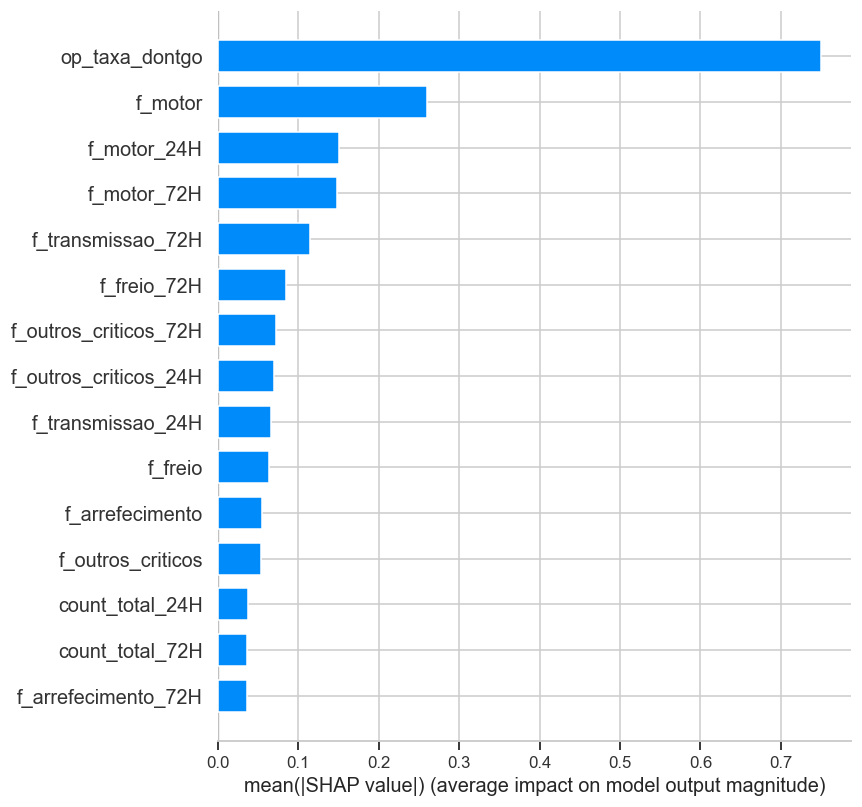


=== SHAP — Beeswarm: Impacto e Direção ===


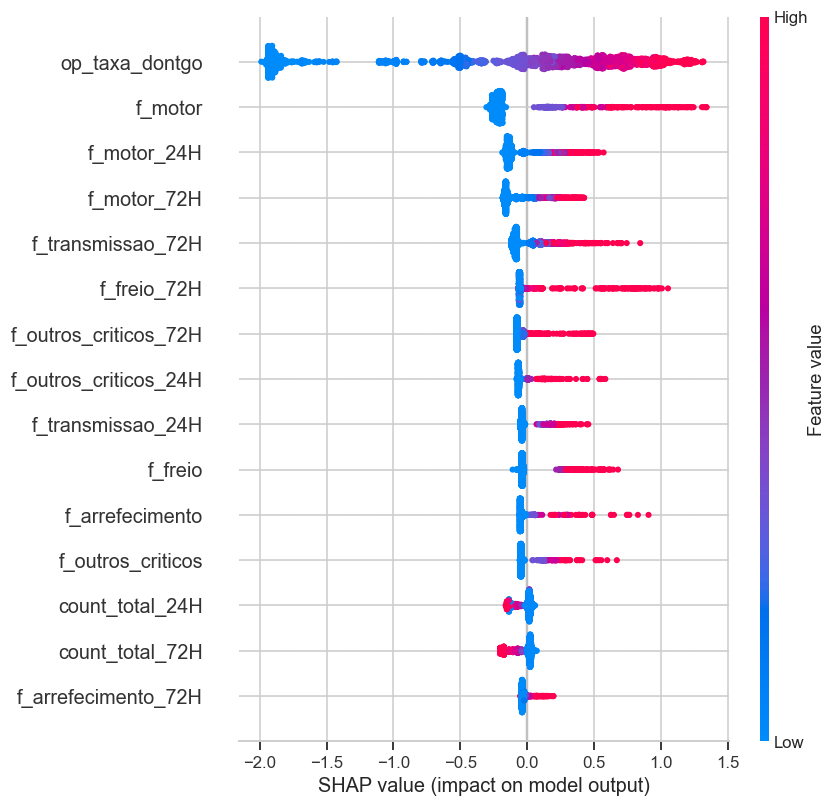

In [19]:
import shap

# Usando o melhor modelo CatBoost do Esquema 1
modelo_shap = best_cat_e1

explainer   = shap.TreeExplainer(modelo_shap)
shap_values = explainer.shap_values(X_te)

print("=== SHAP — Importância Global das Features (Esquema 1) ===")
shap.summary_plot(shap_values, X_te, plot_type='bar', max_display=15, show=True)

print("\n=== SHAP — Beeswarm: Impacto e Direção ===")
shap.summary_plot(shap_values, X_te, max_display=15, show=True)


## Persistência do Modelo Vencedor


In [20]:
melhor_nome = df_roi.iloc[0]['Modelo']
print(f"Modelo vencedor (ROI): {melhor_nome}")

# Mapear nome para objeto
modelo_map = {
    'CatBoost_E1': best_cat_e1,
    'CatBoost_E2': best_cat_e2,
    'CatBoost_E3': best_cat_e3,
    'XGBoost_E1': best_xgb,
    'LightGBM_E1': best_lgb,
}
modelo_final = modelo_map.get(melhor_nome, best_cat_e1)

caminho = r'c:\\TT\\AntiGravity\\Vale_\\models\\modelo_definitivo.pkl'
joblib.dump(modelo_final, caminho)
print(f"Modelo salvo: {caminho}")


Modelo vencedor (ROI): RandomForest_E2
Modelo salvo: c:\\TT\\AntiGravity\\Vale_\\models\\modelo_definitivo.pkl
